**Nama:** Shinta Nuraini

**NPM:** 25083010021

**Kelas:** Analisis Numerik A083

**Tugas:** Regresi dan Pencarian Akar

**Analisis Regresi dan Pencarian Break-Even Point pada Lima Gerai Donat**

Analisis ini dilakukan terhadap data laba/rugi harian dari lima gerai donat dengan strategi marketing yang berbeda, yaitu Gerai A (Premium Gourmet), Gerai B (Mass Market Volume), Gerai C (Promo Agresif), Gerai D (Mall Premium Flagship), dan Gerai E (Cloud Kitchen).

Analisis yang dilakukan meliputi:
1. Visualisasi hubungan jumlah penjualan dengan revenue.
2. Penerapan regresi untuk mengetahui bentuk tren revenue berdasarkan volume penjualan.
3. Pencarian titik Break-Even Point (BEP) menggunakan hasil regresi dan metode pencarian akar (bisection).
4. Perbandingan hasil BEP dari masing-masing gerai.


**1. IMPORT LIBRARY & MEMBACA DATASET**

Library yang digunakan adalah pandas untuk membaca dan mengolah dataset, numpy untuk perhitungan numerik, matplotlib untuk visualisasi, dan scikit-learn untuk regresi linear

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [176]:
df = pd.read_csv('sintesis_data_donat_harian.csv')
df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


In [177]:
df.info()

print("Jumlah baris dan kolom:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB
Jumlah baris dan kolom: (450, 8)


In [178]:
# Mengecek apakah terdapat nilai kosong pada setiap kolom
print("Jumlah missing values per kolom:")
print(df.isnull().sum())

# Menampilkan daftar nama gerai yang terdapat dalam dataset
print("\nDaftar gerai:")
print(df['Gerai'].unique())

# Menghitung jumlah data untuk setiap gerai
print("\nJumlah baris per gerai:")
print(df['Gerai'].value_counts())

Jumlah missing values per kolom:
Tanggal                   0
Gerai                     0
Harga Jual (Rp)           0
Jumlah Terjual (Unit)     0
Pendapatan Kotor (Rp)     0
Biaya Variabel (Rp)       0
Fixed Cost Harian (Rp)    0
Balance (Rp)              0
dtype: int64

Daftar gerai:
['Gerai A' 'Gerai B' 'Gerai C' 'Gerai D' 'Gerai E']

Jumlah baris per gerai:
Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: count, dtype: int64


**2. HUBUNGAN VOLUME PENJUALAN DAN REVENUE**

Langkah berikutnya adalah melihat langsung bagaimana bentuk hubungan antara banyaknya donat yang terjual dengan pendapatan kotor yang dihasilkan.

Sumbu yang dipakai:
- X: Jumlah Terjual (Unit)
- Y: Pendapatan Kotor (Rp)

Tujuannya sederhana: sebelum menentukan model regresi apa yang cocok, kita perlu lihat dulu polanya secara visual untuk masing-masing gerai.

In [179]:
# Mengambil daftar gerai secara berurutan
gerai_list = sorted(df['Gerai'].unique())
data_by_gerai = {g: df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)').reset_index(drop=True)
              for g in gerai_list}

for g in gerai_list:
    print(g, "-> jumlah hari data:", len(data_by_gerai[g]))

Gerai A -> jumlah hari data: 90
Gerai B -> jumlah hari data: 90
Gerai C -> jumlah hari data: 90
Gerai D -> jumlah hari data: 90
Gerai E -> jumlah hari data: 90


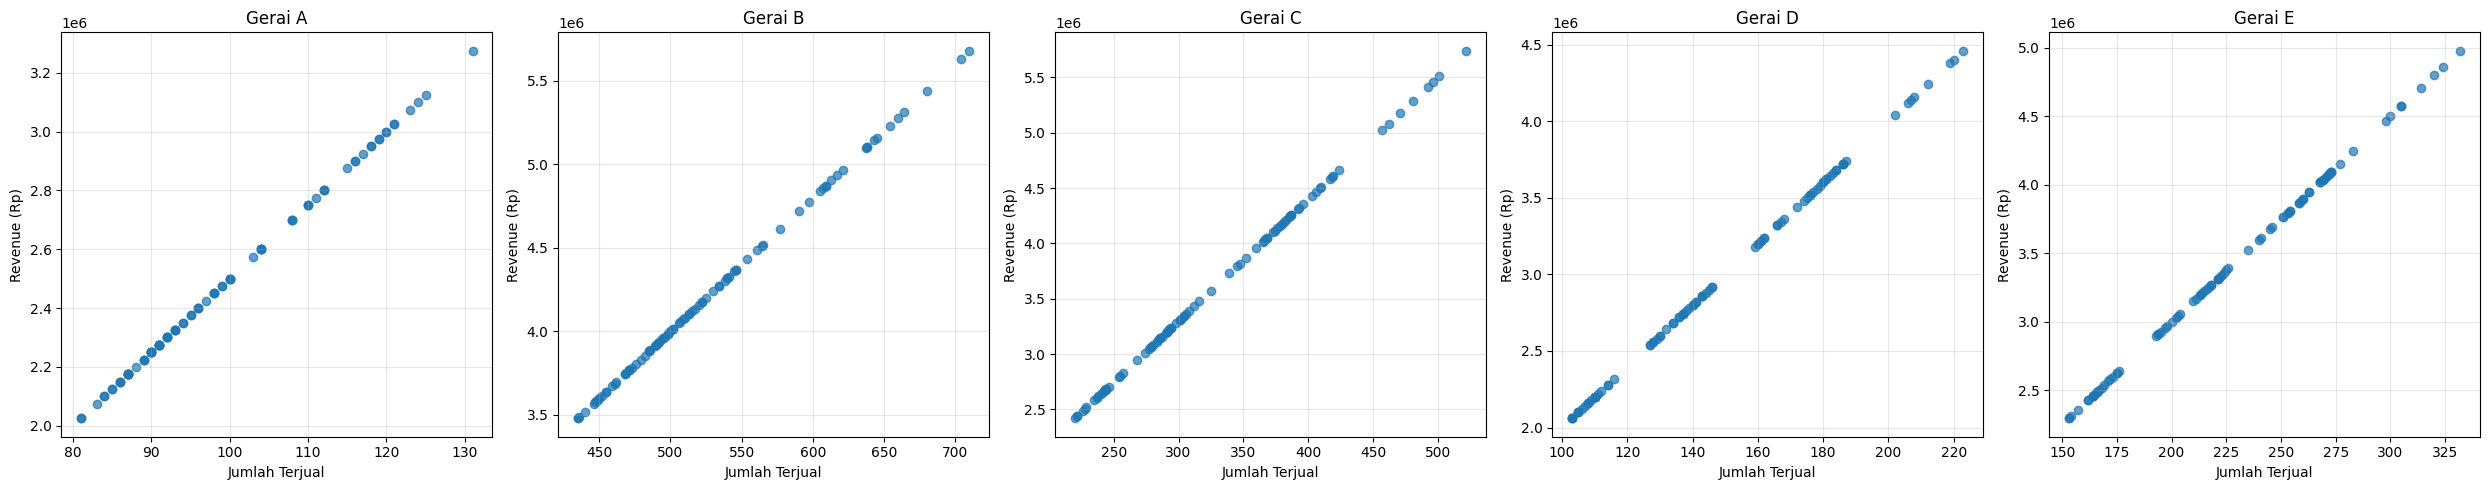

In [180]:
# Mengambil daftar gerai secara berurutan
gerai_list = sorted(df['Gerai'].unique())

# Membuat 5 grafik berdampingan, satu untuk tiap gerai
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, gerai in zip(axes, gerai_list):

    # Mengambil data berdasarkan nama gerai
    data_gerai = df[df['Gerai'] == gerai]

    # Membuat scatter plot
    ax.scatter(
        data_gerai['Jumlah Terjual (Unit)'],
        data_gerai['Pendapatan Kotor (Rp)'],
        alpha=0.7
    )

    ax.set_title(gerai)
    ax.set_xlabel('Jumlah Terjual')
    ax.set_ylabel('Revenue (Rp)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

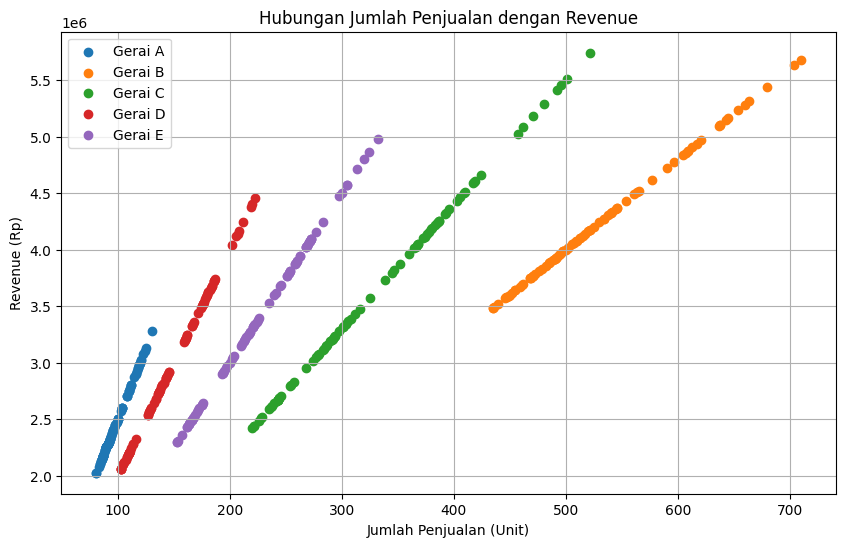

In [181]:
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():
    data_gerai = df[df["Gerai"] == gerai]

    plt.scatter(
        data_gerai["Jumlah Terjual (Unit)"],
        data_gerai["Pendapatan Kotor (Rp)"],
        label=gerai
    )

plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.title("Hubungan Jumlah Penjualan dengan Revenue")
plt.legend()
plt.grid(True)
plt.show()

Dari kelima grafik terlihat pola yang sama: titik-titik datanya membentuk garis lurus naik, bukan lengkungan atau sebaran acak. Semakin banyak donat terjual, semakin besar pula revenue-nya, dan kenaikannya konsisten.

Ini sebetulnya wajar kalau ditelusuri dari rumusnya:

**Revenue = Harga Jual × Jumlah Terjual**

Karena harga jual di tiap gerai tidak berubah dari hari ke hari, setiap tambahan satu unit terjual selalu menambah revenue dengan jumlah yang sama persis (sebesar harga satuannya) — itulah sebabnya pola di kelima gerai terlihat sangat linear.

Berdasarkan hasil visualisasi tersebut, digunakan regresi linear untuk memodelkan hubungan antara jumlah penjualan sebagai variabel independen dan revenue sebagai variabel dependen. Hasil regresi kemudian dievaluasi menggunakan nilai R².

**3. MEMBANGUN MODEL REGRESI REVENUE**

Karena polanya sudah terlihat linear, langkah selanjutnya adalah mencari persamaan garisnya lewat regresi linear:

**Revenue = a + bX**

Keterangan:
- Y = revenue
- X = jumlah unit donat terjual
- a = intercept (titik potong sumbu Y)
- b = koefisien regresi, yaitu kemiringan garis

Model dibangun dengan LinearRegression dari scikit-learn untuk tiap gerai secara terpisah. Objek model yang sudah dilatih ini disimpan dalam sebuah dictionary agar nanti bisa langsung dipakai lagi saat menghitung BEP, tanpa perlu melatih ulang dari nol.

In [182]:
# Dictionary untuk menyimpan objek model regresi (dipakai ulang di tahap BEP)
model_gerai = {}

# List untuk menyimpan ringkasan hasil regresi tiap gerai
hasil_regresi = []

for gerai in gerai_list:

    # Mengambil data gerai
    data_gerai = df[df['Gerai'] == gerai]

    # Variabel X = jumlah penjualan, Y = revenue
    X = data_gerai[['Jumlah Terjual (Unit)']]
    Y = data_gerai['Pendapatan Kotor (Rp)']

    # Melakukan regresi linear
    model = LinearRegression()
    model.fit(X, Y)

    # Menyimpan model supaya tidak perlu di-fit ulang nanti
    model_gerai[gerai] = model

    # Mengambil intercept, koefisien, dan R^2
    a = model.intercept_
    b = model.coef_[0]
    r2 = model.score(X, Y)

    hasil_regresi.append({
        'Gerai': gerai,
        'Intercept (a)': a,
        'Koefisien (b)': b,
        'R2': r2
    })

hasil_regresi = pd.DataFrame(hasil_regresi)
hasil_regresi

,Gerai,Intercept (a),Koefisien (b),R2
0,Gerai A,-4.656613e-10,25000.0,1.0
1,Gerai B,0.000000e+00,8000.0,1.0
2,Gerai C,4.656613e-10,11000.0,1.0
3,Gerai D,-9.313226e-10,20000.0,1.0
4,Gerai E,-4.656613e-10,15000.0,1.0


In [183]:
# Menampilkan persamaan regresi tiap gerai
for _, row in hasil_regresi.iterrows():
    print(
        f"{row['Gerai']}: "
        f"Revenue = {row['Intercept (a)']:.2f} + "
        f"{row['Koefisien (b)']:.2f} \u00d7 Jumlah Penjualan "
        f"(R\u00b2 = {row['R2']:.4f})"
    )

Gerai A: Revenue = -0.00 + 25000.00 × Jumlah Penjualan (R² = 1.0000)
Gerai B: Revenue = 0.00 + 8000.00 × Jumlah Penjualan (R² = 1.0000)
Gerai C: Revenue = 0.00 + 11000.00 × Jumlah Penjualan (R² = 1.0000)
Gerai D: Revenue = -0.00 + 20000.00 × Jumlah Penjualan (R² = 1.0000)
Gerai E: Revenue = -0.00 + 15000.00 × Jumlah Penjualan (R² = 1.0000)


Ternyata koefisien (b) yang diperoleh dari regresi persis sama dengan harga jual masing-masing gerai — bukan kebetulan, karena memang revenue dihitung langsung sebagai harga dikali unit tanpa ada komponen acak. Ini juga yang membuat nilai R² di kelima gerai mencapai angka 1: modelnya menjelaskan datanya secara sempurna, tidak ada penyimpangan sama sekali.

R² digunakan untuk melihat seberapa baik model regresi menjelaskan hubungan antara jumlah penjualan dengan revenue.

Nilai R² semakin mendekati 1, berarti model semakin sesuai dengan data.

Pada dataset ini, nilai R² akan sangat tinggi karena revenue memiliki hubungan langsung dengan jumlah produk yang terjual.

**4. MENYUSUN FUNGSI BIAYA TOTAL**

Sebelum bisa mencari titik impas, kita butuh fungsi biaya total-nya juga, dengan bentuk:

**Biaya Total(X) = (biaya variabel per unit × X) + fixed cost harian**

Nilai biaya variabel per unit diperoleh dengan membagi Biaya Variabel (Rp) dengan Jumlah Terjual (Unit) pada tiap baris, lalu dirata-rata per gerai.

In [184]:
# Menghitung biaya variabel per unit untuk setiap baris data
df['Biaya Variabel per Unit (Rp)'] = (
    df['Biaya Variabel (Rp)'] / df['Jumlah Terjual (Unit)']
)

# Dictionary untuk menyimpan rata-rata biaya variabel/unit dan fixed cost per gerai
biaya_gerai = {}

for gerai in gerai_list:
    data_gerai = df[df['Gerai'] == gerai]

    v = data_gerai['Biaya Variabel per Unit (Rp)'].mean()
    fc = data_gerai['Fixed Cost Harian (Rp)'].mean()

    biaya_gerai[gerai] = {'v': v, 'fc': fc}

    print(f"{gerai}: biaya variabel/unit = Rp{v:,.2f}, fixed cost harian = Rp{fc:,.0f}")

Gerai A: biaya variabel/unit = Rp8,500.00, fixed cost harian = Rp1,683,333
Gerai B: biaya variabel/unit = Rp4,160.00, fixed cost harian = Rp733,333
Gerai C: biaya variabel/unit = Rp4,840.00, fixed cost harian = Rp1,733,333
Gerai D: biaya variabel/unit = Rp7,200.00, fixed cost harian = Rp2,666,666
Gerai E: biaya variabel/unit = Rp6,300.00, fixed cost harian = Rp800,000


**5. MENCARI TITIK BEP LEWAT METODE BISECTION**

Titik impas (BEP) tercapai ketika revenue persis sama dengan total biaya — dengan kata lain, laba/rugi hari itu nol. Ini bisa dituliskan sebagai fungsi selisih:

**f(X) = Revenue(X) − Biaya Total(X) = (b − v)X + (a − fc)**

BEP adalah nilai X yang membuat **f(X) = 0**. Karena bentuknya linear, sebenarnya akarnya bisa langsung dihitung pakai aljabar (X = (fc - a) / (b - v)). Tapi berhubung tugas ini memang fokus melatih **metode numerik pencarian akar**, di sini dipakai **Bisection** yang ditulis manual, tanpa mengandalkan fungsi bawaan library manapun.

In [185]:
# Fungsi untuk mencari akar menggunakan metode Bisection
def bisection(f, a, b, tol=1e-6, max_iter=100):

    # Menghitung nilai fungsi pada batas bawah dan batas atas
    fa = f(a)
    fb = f(b)

    # Memastikan terdapat akar dalam interval (tanda f(a) dan f(b) harus berbeda)
    if fa * fb > 0:
        raise ValueError("Interval tidak mengandung akar.")

    # Melakukan iterasi
    for i in range(max_iter):

        # Menghitung titik tengah interval
        c = (a + b) / 2
        fc_val = f(c)

        # Jika nilai fungsi sudah sangat dekat dengan nol, akar dianggap ditemukan
        if abs(fc_val) < tol:
            return c, i + 1

        # Menentukan interval baru berdasarkan tanda f(c)
        if fa * fc_val < 0:
            b, fb = c, fc_val
        else:
            a, fa = c, fc_val

    # Mengembalikan hasil jika iterasi maksimum tercapai
    return c, max_iter

In [186]:
# Dictionary untuk menyimpan hasil BEP tiap gerai
hasil_bep = {}

for gerai in gerai_list:

    # Mengambil model regresi revenue yang sudah di-fit sebelumnya
    model = model_gerai[gerai]
    a = model.intercept_
    b = model.coef_[0]

    # Mengambil biaya variabel/unit dan fixed cost gerai ini
    v = biaya_gerai[gerai]['v']
    fc = biaya_gerai[gerai]['fc']

    # Membuat fungsi selisih f(X) = Revenue(X) - Biaya Total(X)
    def f_selisih(x, a=a, b=b, v=v, fc=fc):
        revenue = a + b * x
        biaya_total = v * x + fc
        return revenue - biaya_total

    # Mengambil data gerai untuk menentukan rentang pencarian
    data_gerai = df[df['Gerai'] == gerai]

    # Interval pencarian dimulai dari mendekati nol, karena BEP bisa berada
    # di luar rentang volume penjualan harian yang tercatat
    batas_bawah = 0.0001  # Mendekati nol untuk menghindari log(0) atau pembagian nol
    batas_atas = data_gerai['Jumlah Terjual (Unit)'].max()

    # Jika f(batas_bawah) dan f(batas_atas) memiliki tanda yang sama, perluas batas_atas
    while f_selisih(batas_bawah) * f_selisih(batas_atas) > 0:
        batas_atas *= 2

    # Mencari akar dengan metode Bisection
    akar, iterasi = bisection(
    f_selisih,
    batas_bawah,
    batas_atas
    )

    # Menyimpan hasil
    hasil_bep[gerai] = {
        'bep': akar,
        'iterasi': iterasi
    }

# Menampilkan hasil
for gerai in gerai_list:
    h = hasil_bep[gerai]
    print(
        f"{gerai}: BEP (bisection) = {h['bep']:.2f} unit, "
        f"Iterasi = {h['iterasi']}"
    )

Gerai A: BEP (bisection) = 102.02 unit, Iterasi = 40
Gerai B: BEP (bisection) = 190.97 unit, Iterasi = 40
Gerai C: BEP (bisection) = 281.39 unit, Iterasi = 41
Gerai D: BEP (bisection) = 208.33 unit, Iterasi = 40
Gerai E: BEP (bisection) = 91.95 unit, Iterasi = 40


Setelah dicek, hasil Bisection ini juga sangat dekat dengan hitungan aljabar langsung (X = (fc - a) / (b - v)) — wajar, karena fungsi selisihnya memang linear sehingga akarnya tunggal dan pasti sama di mana pun cara menghitungnya. Perbedaan besaran BEP antar gerai sendiri terjadi karena tiap gerai punya kombinasi harga jual, biaya variabel per unit, dan fixed cost yang berbeda-beda.

**6. MEMVISUALISASIKAN GARIS REVENUE, BIAYA, DAN TITIK BEP**

Untuk memastikan hasil perhitungan di atas masuk akal, garis regresi revenue, garis biaya total, dan titik BEP masing-masing gerai digambarkan bersamaan dalam satu baris grafik.

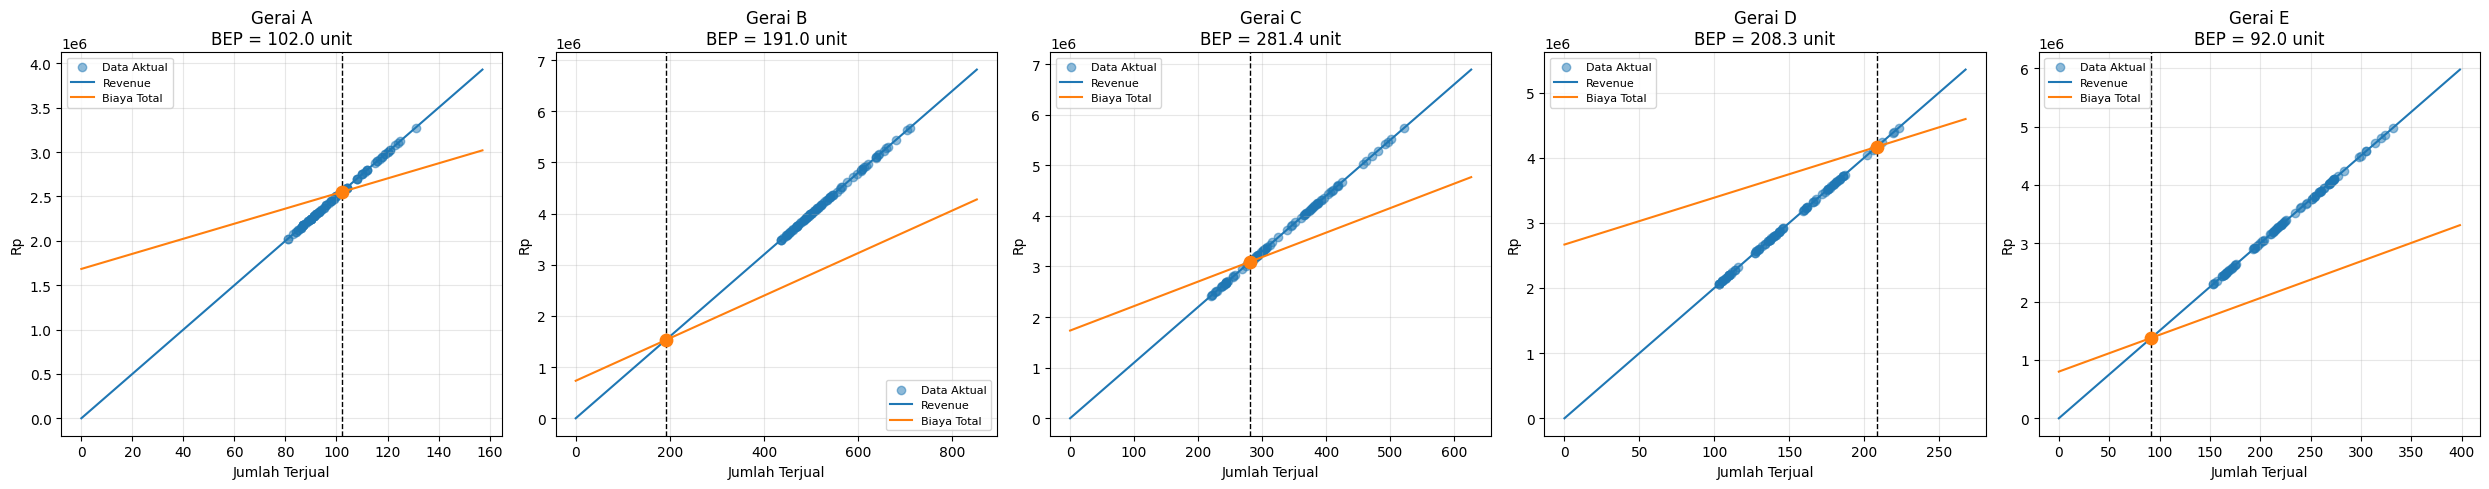

In [187]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, gerai in zip(axes, gerai_list):

    data_gerai = df[df['Gerai'] == gerai]

    model = model_gerai[gerai]
    a = model.intercept_
    b = model.coef_[0]
    v = biaya_gerai[gerai]['v']
    fc = biaya_gerai[gerai]['fc']
    bep = hasil_bep[gerai]['bep']

    # Rentang X untuk garis regresi & biaya, diperlebar sedikit melewati BEP
    X_line = np.linspace(
        0,
        max(data_gerai['Jumlah Terjual (Unit)'].max(), bep) * 1.2,
        100
    )
    revenue_line = a + b * X_line
    biaya_line = v * X_line + fc

    # Data aktual
    ax.scatter(
        data_gerai['Jumlah Terjual (Unit)'],
        data_gerai['Pendapatan Kotor (Rp)'],
        alpha=0.5, label='Data Aktual'
    )

    # Garis regresi revenue & garis biaya total
    ax.plot(X_line, revenue_line, label='Revenue')
    ax.plot(X_line, biaya_line, label='Biaya Total')

    # Garis vertikal & titik BEP
    ax.axvline(bep, linestyle='--', linewidth=1, color='black')
    ax.scatter(
    [bep],
    [a + b * bep],
    s=80,
    zorder=5
    )

    ax.set_title(f'{gerai}\nBEP = {bep:.1f} unit')
    ax.set_xlabel('Jumlah Terjual')
    ax.set_ylabel('Rp')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Bisa dilihat garis revenue dan garis biaya total memang berpotongan tepat di titik yang ditandai sebagai BEP. Di sebelah kiri titik itu, biaya masih lebih besar dari revenue sehingga posisinya rugi; begitu melewati titik itu ke kanan, revenue sudah melampaui biaya dan gerai mulai untung.

**7. RANGKUMAN AKHIR & PERBANDINGAN ANTAR GERAI**

In [188]:
hasil_akhir = []

for gerai in gerai_list:

    model = model_gerai[gerai]

    a = model.intercept_
    b = model.coef_[0]

    r2 = hasil_regresi.loc[
        hasil_regresi['Gerai'] == gerai,
        'R2'
    ].values[0]

    v = biaya_gerai[gerai]['v']
    fc = biaya_gerai[gerai]['fc']
    bep = hasil_bep[gerai]['bep']

    persamaan_revenue = f"Y = {a:,.2f} + {b:,.2f}X"

    hasil_akhir.append({
        'Gerai': gerai,
        'Persamaan Revenue': persamaan_revenue,
        'R²': r2,
        'Biaya Variabel/Unit (Rp)': v,
        'Fixed Cost (Rp)': fc,
        'BEP (Unit)': bep,
        'Minimal Penjualan (Unit)': np.ceil(bep)
    })

tabel_hasil = pd.DataFrame(hasil_akhir)

display(
    tabel_hasil.style
    .format({
        'R²': '{:.4f}',
        'Biaya Variabel/Unit (Rp)': 'Rp {:,.0f}',
        'Fixed Cost (Rp)': 'Rp {:,.0f}',
        'BEP (Unit)': '{:.2f}',
        'Minimal Penjualan (Unit)': '{:.0f}'
    })
    .set_caption('Tabel Hasil Analisis Regresi dan Break-Even Point')
)

,Gerai,Persamaan Revenue,R²,Biaya Variabel/Unit (Rp),Fixed Cost (Rp),BEP (Unit),Minimal Penjualan (Unit)
0,Gerai A,"Y = -0.00 + 25,000.00X",1.0000,"Rp 8,500","Rp 1,683,333",102.02,103
1,Gerai B,"Y = 0.00 + 8,000.00X",1.0000,"Rp 4,160","Rp 733,333",190.97,191
2,Gerai C,"Y = 0.00 + 11,000.00X",1.0000,"Rp 4,840","Rp 1,733,333",281.39,282
3,Gerai D,"Y = -0.00 + 20,000.00X",1.0000,"Rp 7,200","Rp 2,666,666",208.33,209
4,Gerai E,"Y = -0.00 + 15,000.00X",1.0000,"Rp 6,300","Rp 800,000",91.95,92


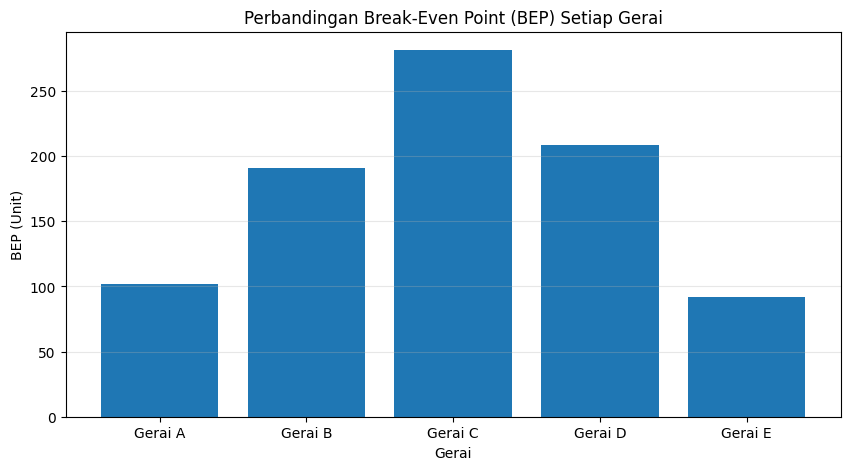

In [189]:
# Grafik perbandingan BEP setiap gerai
plt.figure(figsize=(10, 5))

plt.bar(tabel_hasil['Gerai'], tabel_hasil['BEP (Unit)'])

plt.title('Perbandingan Break-Even Point (BEP) Setiap Gerai')
plt.xlabel('Gerai')
plt.ylabel('BEP (Unit)')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Kesimpulan**

Berdasarkan hasil visualisasi, hubungan antara jumlah penjualan dan revenue pada kelima gerai menunjukkan pola linear. Oleh karena itu, digunakan metode regresi linear untuk memodelkan hubungan antara volume penjualan dan revenue. Hasil regresi menunjukkan nilai R² sebesar 1 pada seluruh gerai, yang berarti model linear dapat menjelaskan hubungan tersebut secara sempurna pada dataset. Hal ini disebabkan oleh revenue yang dihitung berdasarkan harga jual dikalikan dengan jumlah produk yang terjual.

Selanjutnya, Break-Even Point (BEP) ditentukan dengan mencari akar dari fungsi selisih antara revenue dan biaya total menggunakan metode Bisection. Hasil perhitungan menunjukkan bahwa masing-masing gerai memiliki jumlah penjualan minimum yang berbeda untuk mencapai kondisi impas, yaitu:
* Gerai A sebesar 103 unit/hari
* Gerai B sebesar 191 unit/hari
* Gerai C sebesar 282 unit/hari
* Gerai D sebesar 209 unit/hari
* Gerai E sebesar 92 unit/hari

Perbedaan nilai BEP tersebut dipengaruhi oleh perbedaan harga jual, biaya variabel per unit, dan fixed cost harian pada masing-masing gerai.

Dengan demikian, metode regresi linear digunakan untuk membentuk model hubungan antara jumlah penjualan dan revenue, sedangkan metode Bisection digunakan untuk menentukan jumlah penjualan minimum yang diperlukan agar masing-masing gerai mencapai kondisi BEP. Hasil tersebut menunjukkan bahwa setiap gerai memiliki target penjualan harian yang berbeda untuk mencapai titik impas.